In [1]:
import os
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader, get_worker_info, random_split
import tarfile
import json
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.optim as optim  
import math
import matplotlib.pyplot as plt
import numpy as np
import random
import time

/home/oscar/miniconda3/envs/torch_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set Random Seed

In [2]:
torch.manual_seed(42)
random.seed(42)

## Initialise GPU

In [3]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

GPU: NVIDIA GeForce RTX 3060 Laptop GPU is available.
cuda


## Creating Dataset Class

In [4]:
class MultiCameraDataset(Dataset):
    def __init__(self, json_path, videos_dir, transform, max_offset = 500):
        # carregant el json
        with open(json_path) as f:
            all_data = json.load(f)
        
        #Filtrant aquells que tingin boundary = 1
        self.metadata = []
        max_cam_id = 0
        for entry in all_data:
            if entry.get('boundary') == 1:

                more_than_max = False

                c_f = entry["CAMFrame"]
                
                for past_f in entry["outputList"]:
                    if ((c_f - past_f) >= max_offset) or ((c_f - past_f) < 0):
                        more_than_max = True
                        break
                
                if more_than_max == False:
                    self.metadata.append(entry)
                
                    camera_ids = [int(c.replace("CAM", "")) for c in entry["CAMList"]]
                    camera_ids.append(int(entry["currentCam"].replace("CAM", "")))
                    m = max(camera_ids)
                    if max_cam_id < m:
                        max_cam_id = m

        print(f"Maximum camera ID: {max_cam_id}")
            
        self.frames_dir = videos_dir
        self.transform = transform
        self.maximum_offset = max_offset

    def __len__(self):
        return len(self.metadata)

    def transform_camera_ID_to_tensor(self, cameraID):
        cam_id_number = cameraID.replace("CAM", "")

        cam_id_tensor = torch.tensor(int(cam_id_number) - 1, dtype=torch.long)

        return cam_id_tensor

    def load_frame(self, 
                   video_name, frame, cameras,
                   past_frames, curr_camera
                  ):

        candidate_frames_to_tensor = []
        camera_Ids_tensor = []

        # Load all candidate frames
        for camera in cameras:
                
            #member = tar_file.getmember(os.path.join(video_name, camera, f"{frame}.jpg"))
            path = os.path.join(self.frames_dir,video_name, camera, f"{frame}.jpg")
            
            # Loading image
            img = Image.open(path).convert("RGB")

            candidate_frames_to_tensor.append(self.transform(img))
                

            # Transform camera Id to tensor and append it to list
            camera_Ids_tensor.append(self.transform_camera_ID_to_tensor(camera))

        # To not uncompress the tar file again, load here past frames too
        past_f, offsets = self.load_multiple_frames(video_name, past_frames, curr_camera, frame)

        return candidate_frames_to_tensor, camera_Ids_tensor, past_f, offsets


    def load_multiple_frames(self, video_name, frames, camera, current_frame):

        frames_to_tensor = []

        past_frame_offsets = []

        # Load all frames listed
        for frame in sorted(frames):
            # Computing frame offset with current position
            offset = current_frame - frame
            # checking if offset is lower than max offset, if it is not, do not take this past frame into account
            if offset < self.maximum_offset:
                past_frame_offsets.append(torch.tensor(offset))
                #member = tarfile_opened.getmember(os.path.join(video_name, camera, f"{frame}.jpg"))
                path = os.path.join(self.frames_dir,video_name, camera, f"{frame}.jpg")
                
                
                img = Image.open(path).convert("RGB")

    
                frames_to_tensor.append(self.transform(img))

        return frames_to_tensor, past_frame_offsets

    
    def __getitem__(self, idx):
        
        ## Retrieve frame, frame offset and camera ID

        entry = self.metadata[idx]

        video = entry["videoID"]

        frame = entry["CAMFrame"]

        previous_frames = entry["outputList"]

        current_camera = entry["currentCam"]

        candidate_cameras = entry["CAMList"]

        selected_camera = entry["selectCAM"]

        ## Retrieve candidate frames and transform them into tensors
        candidate_frames, candidate_cameras_tensor, past_frames, frame_offsets = self.load_frame(
            video, frame, candidate_cameras,
            previous_frames, "output"
        )

        ## Return everything as tensors
        cand_frames = torch.stack(candidate_frames)
        cand_cameras_tensor = torch.stack(candidate_cameras_tensor)
        frame_offset_tensor = torch.stack(frame_offsets)
        past_frames_tensor = torch.stack(past_frames)
        selected_cam = self.transform_camera_ID_to_tensor(selected_camera)
        current_camera_tensor = self.transform_camera_ID_to_tensor(current_camera)
        
        return cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam

## Training Data Loader

In [5]:
transform_image_tensor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_d = MultiCameraDataset(
    'TVMCE/meta/train.json', 
    'TVMCE/train',
    transform_image_tensor
)

Maximum camera ID: 12


In [6]:
print(len(train_d))

4034


In [7]:
#Split training data into training and validation in a 90% 10% proportion
dataset_training_size = len(train_d)
train_size = int(0.9*dataset_training_size)
val_size = dataset_training_size - train_size

training_dataset, validation_dataset = random_split(train_d, [train_size, val_size])

In [8]:
print("Training Dataset size:", len(training_dataset))
print("Validation Dataset size:", len(validation_dataset))

Training Dataset size: 3630
Validation Dataset size: 404


In [9]:
train_loader = DataLoader(
    training_dataset,
    batch_size=4,      # tamaño de batch
    shuffle=True       # barajar datos cada epoch
    #persistent_workers=True
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=4,      # tamaño de batch
    shuffle=True       # barajar datos cada epoch
    #persistent_workers=True
)

In [10]:
for batch in train_loader:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 256, 256])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 256, 256])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


In [11]:
for batch in val_loader:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 256, 256])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 256, 256])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


## Feature extractor

In [12]:
class FeatureExtractor(nn.Module):
    def __init__(self, num_cameras = 6, dim = 768):
        super().__init__()

        # Feature extraction of image
        self.backbone = timm.create_model(
            'swinv2_tiny_window8_256',
            pretrained=True,
            num_classes=0,  # remove classifier nn.Linear
        )

        # Freezing backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Embedding layer for camera ID
        self.camera_embedding =  nn.Embedding(num_embeddings=num_cameras,embedding_dim=dim)

    def offset_positional_encoding(self, offsets, d_model=768):
        # This positional encoding function has been done by Josep Cabacas Maso
        device = offsets.device
        offs = offsets.clamp(min=0, max=500).unsqueeze(-1).float()
        idx = torch.arange(0, d_model, 2, device=device).float()
        inv_freq = 1.0 / (10000.0 ** (idx / d_model))
        ang = offs * inv_freq
        pe = torch.zeros((*offs.shape[:-1], d_model), device=device)
        pe[..., 0::2] = torch.sin(ang)
        pe[..., 1::2] = torch.cos(ang)
        return pe

    def forward(self, frame, frame_offset, camera_id):

        # Flatening frame so it has the dimensions required by Swin transformer
        B, S, C, H, W = frame.shape
        frame_flat = frame.view(B * S, C, H, W)
        
        # Swin transformer, freezing gradients as backbone is freezed
        with torch.no_grad():
            image_features = self.backbone(frame_flat)

        
        image_features = image_features.view(B, S, -1)
        #offset_emb = self.offset_embedding(frame_offset)
        offset_emb = self.offset_positional_encoding(frame_offset)
        camera_embedding = self.camera_embedding(camera_id)

        return image_features + offset_emb + camera_embedding
        

##  past-candidate mixer

In [13]:
class PastCandidateMixer(nn.Module):
    def __init__(self, dim=768, nheads = 8):
        super().__init__()
        
        # Self-attention layer
        self.attention_layer =nn.MultiheadAttention(embed_dim = dim, num_heads=nheads, batch_first=True)
    def forward(self, feature_vectors):
        # Self attention (MultiheadAttention where query, key, and value tensors are the same)
        # https://www.geeksforgeeks.org/deep-learning/how-to-use-pytorchs-nnmultiheadattention/
        return self.attention_layer(feature_vectors, feature_vectors, feature_vectors)

## MLP

In [14]:
class Multi_Layer_Perception(nn.Module):
    def __init__(self, input_dim = 768, hidden_dim = 192):
        super().__init__()
        # Defining mlp in the same way that is explained in the article
        self.layers = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, candidate_mixed_vectors):

        return self.layers(candidate_mixed_vectors)
        

## Joining everything in a model

In [15]:
class Multi_Camera_View_Recomendation(nn.Module):
    def __init__(self, number_cameras, dimension=768, past_candidate_mixer_heads = 8, mlp_hidden_dimensions=192):
        super().__init__()
        
        # Feature extractors
        self.feat_extractor_past = FeatureExtractor(num_cameras = number_cameras, dim = dimension)
        self.feat_extractor_cand = FeatureExtractor(num_cameras = number_cameras, dim = dimension)

        # Past candidate mixer
        self.past_candidate_mixer = PastCandidateMixer(dim=dimension, nheads = past_candidate_mixer_heads)

        #MLP
        self.MultiLayerPerception = Multi_Layer_Perception(input_dim = dimension, hidden_dim = mlp_hidden_dimensions)

    def forward(self,
                candidate_frames,
                candidate_camera_ids,
                past_frames,
                frame_offsets,
                current_camera_id
               ):

        # Amount of past and candidate frames
        Tpast = past_frames.shape[1]
        NCand = candidate_frames.shape[1]
        # Perform feature extraction on past frames
        past_camera_ids = current_camera_id.unsqueeze(1).expand(-1, Tpast)
        feature_vector_past = self.feat_extractor_past(past_frames, frame_offsets, past_camera_ids)

        # Feature extraction on candidate frames
        # Frame offset for this cases is 0
        cand_frames_offset = torch.zeros_like(candidate_camera_ids)
        feature_vector_cand = self.feat_extractor_cand(candidate_frames, cand_frames_offset, candidate_camera_ids)

        # Concatenate feature vectors to perform self attention with past candidate mixer
        f_vector = torch.cat([feature_vector_past, feature_vector_cand], dim=1)

        # Perform self attention
        att_output, att_weights = self.past_candidate_mixer(f_vector)

        cand_outputs = att_output[:,-NCand:,:]
        
        return self.MultiLayerPerception(cand_outputs)
        

## Training

In [16]:
def test(model, dataloader):

    model.eval()

    BCE_Loss_Function = nn.BCEWithLogitsLoss()

    running_loss = 0.0
    running_acc = 0
    n_samples = 0

    with torch.no_grad():
        # Loop through each data loader batch 
        for batch_ind, batch in enumerate(dataloader):
            # Moving input to GPU
            cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch

            cand_frames = cand_frames.to(device)
            cand_cameras_tensor = cand_cameras_tensor.to(device)
            frame_offset_tensor = frame_offset_tensor.to(device)
            past_frames_tensor = past_frames_tensor.to(device)
            current_camera_tensor= current_camera_tensor.to(device)
            selected_cam = selected_cam.to(device)

            with torch.amp.autocast("cuda"):

                # Run model
                output = model(
                    cand_frames,
                    cand_cameras_tensor,
                    past_frames_tensor,
                    frame_offset_tensor,
                    current_camera_tensor
                )

                scores = output.squeeze(-1)

                targets = (cand_cameras_tensor == selected_cam.unsqueeze(1)).float()

                # Run loss function
                loss = BCE_Loss_Function(scores,targets)

            l = loss.item()
            running_loss += l

            # Computing accuracy
            pred_idx = scores.argmax(dim=1)
            true_idx = targets.argmax(dim=1)
            correct = (pred_idx == true_idx).sum().item()

            total = scores.size(0)

            batch_acc = correct/total

            running_acc += correct
            n_samples += total

            if batch_ind % 100 == 0:

                print(f"Batch {batch_ind}, loss: {l}, accuracy: {batch_acc}")

    # Compute average loss
    av_loss = running_loss / len(dataloader)
    av_acc = running_acc / n_samples
    print(f"Average loss = {av_loss}, average_accuracy = {av_acc}, number of samples = {n_samples}")
            
    return av_loss, av_acc

In [17]:
def train(train_data_loader, val_data_loader, n_epochs = 10, learning_rate = 0.00001, n_cameras = 12):
    # Defining model class
    model = Multi_Camera_View_Recomendation(number_cameras=n_cameras)

    model = model.to(device)

    # Loss function and optimiser
    BCE_Loss_Function = nn.BCEWithLogitsLoss()
    adamW = torch.optim.AdamW(
        model.parameters(),
        lr = learning_rate
    )

    scaler = torch.amp.GradScaler("cuda")

    train_losses = []
    train_acc = []

    val_losses = []
    val_acc = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0
        n_samples = 0
        # Loop through each data loader batch 
        for batch_ind, batch in enumerate(train_data_loader):
            # Moving input to GPU
            cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch

            cand_frames = cand_frames.to(device)
            cand_cameras_tensor = cand_cameras_tensor.to(device)
            frame_offset_tensor = frame_offset_tensor.to(device)
            past_frames_tensor = past_frames_tensor.to(device)
            current_camera_tensor= current_camera_tensor.to(device)
            selected_cam = selected_cam.to(device)

            adamW.zero_grad(set_to_none=True)
            
            with torch.amp.autocast("cuda"):

                # Run model
                output = model(
                    cand_frames,
                    cand_cameras_tensor,
                    past_frames_tensor,
                    frame_offset_tensor,
                    current_camera_tensor
                )

                scores = output.squeeze(-1)

                targets = (cand_cameras_tensor == selected_cam.unsqueeze(1)).float()

                # Run loss function
                loss = BCE_Loss_Function(scores,targets)
                
                #loss.backward()
                #adamW.step()
            
            scaler.scale(loss).backward()
            scaler.step(adamW)
            scaler.update()

            l = loss.item()
            running_loss += l

            # Computing accuracy
            pred_idx = scores.argmax(dim=1)
            true_idx = targets.argmax(dim=1)
            correct = (pred_idx == true_idx).sum().item()

            total = scores.size(0)

            batch_acc = correct/total

            running_acc += correct
            n_samples += total

            if batch_ind % 100 == 0:

                print(f"Batch {batch_ind}, loss: {l}, accuracy: {batch_acc}")

        # Compute average loss of the epoch
        av_loss = running_loss / len(train_data_loader)
        av_acc = running_acc / n_samples
        print(f"Epoch {epoch + 1}, training set average loss = {av_loss}, training set average accuracy = {av_acc}, number of samples = {n_samples}")
        train_losses.append(av_loss)
        train_acc.append(av_acc)

        # Loss and accuracy of validation dataset
        print(f"Epoch {epoch + 1} metrics:")
        loss_validation, accuracy_validation = test(model, val_data_loader)
        val_losses.append(loss_validation)
        val_acc.append(accuracy_validation)
        
            
    return model, train_losses, train_acc, val_losses, val_acc

In [18]:
start_time = time.time()
m, losses, accuracy, validation_losses, validation_accuracy = train(train_loader, val_loader, n_epochs = 10, learning_rate = 0.00001)
end_time = time.time()

Batch 0, loss: 0.6655444502830505, accuracy: 0.5
Batch 100, loss: 0.4469551742076874, accuracy: 0.5
Batch 200, loss: 0.3552430272102356, accuracy: 0.5
Batch 300, loss: 0.3012866973876953, accuracy: 0.75
Batch 400, loss: 0.4002518057823181, accuracy: 0.0
Batch 500, loss: 0.33479374647140503, accuracy: 0.5
Batch 600, loss: 0.2937023341655731, accuracy: 0.75
Batch 700, loss: 0.3419455885887146, accuracy: 0.5
Batch 800, loss: 0.4195064902305603, accuracy: 0.25
Batch 900, loss: 0.2946413457393646, accuracy: 0.5
Epoch 1, training set average loss = 0.3739380399626782, training set average accuracy = 0.44490358126721763, number of samples = 3630
Epoch 1 metrics:
Batch 0, loss: 0.4794940650463104, accuracy: 0.25
Batch 100, loss: 0.24761921167373657, accuracy: 0.75
Average loss = 0.33930108393772995, average_accuracy = 0.5272277227722773, number of samples = 404
Batch 0, loss: 0.2480435073375702, accuracy: 0.75
Batch 100, loss: 0.24468128383159637, accuracy: 0.75
Batch 200, loss: 0.265657693147

In [19]:
print("Training lasted", end_time - start_time,"seconds")

Training lasted 6394.027021884918 seconds


In [20]:
print(losses, accuracy, sep="\n\n") 
print(validation_losses, validation_accuracy, sep="\n\n") 

[0.3739380399626782, 0.31012656881847306, 0.2769701539288533, 0.2504451865010325, 0.23282163686196972, 0.20888909694660734, 0.19638775783028897, 0.18670662229527854, 0.1779286952336454, 0.16647820803644506]

[0.44490358126721763, 0.5663911845730027, 0.6451790633608815, 0.6972451790633609, 0.7355371900826446, 0.7881542699724517, 0.8052341597796143, 0.8176308539944903, 0.837465564738292, 0.8471074380165289]
[0.33930108393772995, 0.3049630900420765, 0.29181142549703615, 0.2814377946133661, 0.26066529219693474, 0.2648387974736714, 0.2485440672550461, 0.25797868844601185, 0.24650142253330437, 0.24675972582680164]

[0.5272277227722773, 0.6039603960396039, 0.599009900990099, 0.6435643564356436, 0.7054455445544554, 0.698019801980198, 0.7128712871287128, 0.6905940594059405, 0.7252475247524752, 0.75]


In [21]:
print("Maximum Training Loss and accuracy:", min(losses), max(accuracy))
print("Maximum Validation Loss and accuracy:", min(validation_losses), max(validation_accuracy))

Maximum Training Loss and accuracy: 0.16647820803644506 0.8471074380165289
Maximum Validation Loss and accuracy: 0.24650142253330437 0.75


## Saving model

In [22]:
torch.save(m.state_dict(), "Multi_Camera_Model_State_Directory.pth")

## Plot training metrics

In [23]:
def make_line_plot(xpoints, ypoints_one, ypoints_two, ylab = "", title = "", linecolor_one="b", linecolor_two="r", legend_line_one = "Entrenament", legend_line_two = "Validació"):
    plt.plot(xpoints, ypoints_one, linestyle = 'solid', color = linecolor_one, label = legend_line_one)
    plt.plot(xpoints, ypoints_two, linestyle = 'solid', color = linecolor_two, label = legend_line_two)
    plt.xlabel("Epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.ylim(top=1, bottom=0)
    plt.xlim(left=1, right=10)
    plt.legend()
    plt.show()

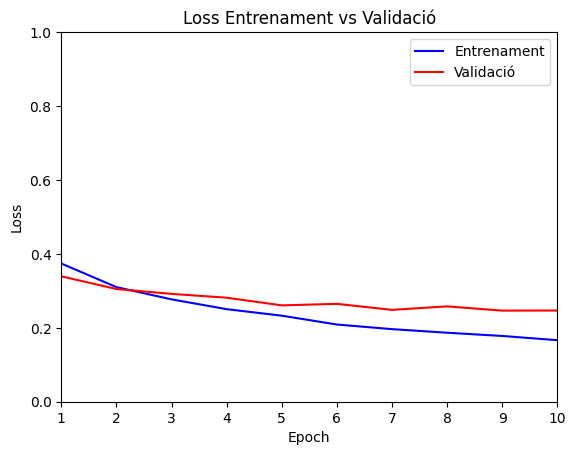

In [24]:
y_loss_train = np.array(losses)
y_loss_val = np.array(validation_losses)
epochs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

make_line_plot(epochs, y_loss_train, y_loss_val, "Loss", "Loss Entrenament vs Validació")

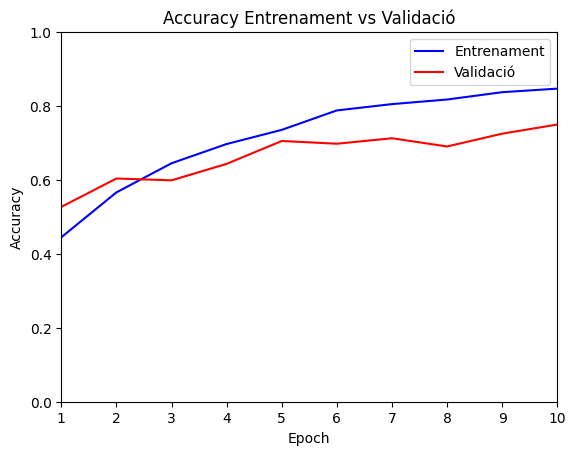

In [25]:
y_acc_train = np.array(accuracy)
y_acc_val = np.array(validation_accuracy)
epochs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

make_line_plot(epochs, y_acc_train, y_acc_val, "Accuracy", "Accuracy Entrenament vs Validació")

## Test

In [26]:
# Creating test dataset and dataloader

test_d = MultiCameraDataset(
    'TVMCE/meta/test.json', 
    'TVMCE/test',
    transform_image_tensor
)

test_lodaer = DataLoader(
    test_d,
    batch_size=4,      # tamaño de batch
    shuffle=True       # barajar datos cada epoch
)

Maximum camera ID: 6


In [27]:
for batch in test_lodaer:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 256, 256])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 256, 256])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


In [28]:
len(test_d)

1087

In [29]:
loss_test, acc_test = test(m, test_lodaer)

Batch 0, loss: 0.2077774852514267, accuracy: 0.75
Batch 100, loss: 0.4460389018058777, accuracy: 0.5
Batch 200, loss: 0.17256593704223633, accuracy: 1.0
Average loss = 0.2761311091701774, average_accuracy = 0.7120515179392825, number of samples = 1087
